In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data=pd.read_csv("05_category_inflows.csv")

In [13]:
data.head(10)

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0
5,2024-04,ELSS,466.0
6,2024-04,Value/Contra,1328.0
7,2024-04,Sectoral/Thematic,8052.0
8,2024-04,Liquid,37537.0
9,2024-04,Short Duration,4400.0


In [14]:
data.tail(11)

,month,category,net_inflow_crore
133,2025-03,Mid Cap,5061.0
134,2025-03,Small Cap,4304.0
135,2025-03,Flexi Cap,4767.0
136,2025-03,Large & Mid Cap,4243.0
137,2025-03,ELSS,500.0
138,2025-03,Value/Contra,1497.0
139,2025-03,Sectoral/Thematic,8614.0
140,2025-03,Liquid,38681.0
141,2025-03,Short Duration,4886.0
142,2025-03,Gilt,956.0


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [16]:
data.describe()

,net_inflow_crore
count,144.000000
mean,6473.881944
std,9718.335947
min,437.000000
25%,1801.250000
50%,4148.000000
75%,5304.000000
max,41952.000000


In [17]:
data.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [18]:
data.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
candidates = ['df', 'data', 'category_data']
df_obj = None
for name in candidates:
    if name in globals():
        df_obj = globals()[name]
        df_name = name
        break
if df_obj is None:
    raise NameError("No dataframe found in globals(). Please run the cell that loads your data (assign to `df` or `data`).")

# choose column: prefer 'nav' if present, otherwise pick the first numeric column
if 'nav' in df_obj.columns:
    col = 'nav'
else:
    num_cols = df_obj.select_dtypes(include='number').columns.tolist()
    if not num_cols:
        raise ValueError('No numeric columns available to check for outliers.')
    col = num_cols[0]

q1 = df_obj[col].quantile(0.25)
q3 = df_obj[col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# add a flag column but do not remove any rows
flag_col = f'is_outlier_{col}'
df_obj[flag_col] = ~df_obj[col].between(lower_bound, upper_bound)

print(f"DataFrame: {df_name}")
print(f"Column checked: {col}")
print(f"IQR: {iqr:.4f} | Lower: {lower_bound:.4f} | Upper: {upper_bound:.4f}")
print('\nOutlier counts:')
print(df_obj[flag_col].value_counts(dropna=False))

# show examples of outliers
from IPython.display import display
print('\nTop 10 outliers by value:')
display(df_obj.loc[df_obj[flag_col]].sort_values(by=col, ascending=False).head(10))

DataFrame: data
Column checked: net_inflow_crore
IQR: 3502.7500 | Lower: -3452.8750 | Upper: 10558.1250

Outlier counts:
is_outlier_net_inflow_crore
False    132
True      12
Name: count, dtype: int64

Top 10 outliers by value:


,month,category,net_inflow_crore,is_outlier_net_inflow_crore
56,2024-08,Liquid,41952.0,True
20,2024-05,Liquid,41872.0,True
92,2024-11,Liquid,40506.0,True
32,2024-06,Liquid,40486.0,True
80,2024-10,Liquid,39091.0,True
140,2025-03,Liquid,38681.0,True
8,2024-04,Liquid,37537.0,True
68,2024-09,Liquid,35308.0,True
104,2024-12,Liquid,34933.0,True
44,2024-07,Liquid,34643.0,True


In [21]:
data["month"].head(10)

0    2024-04
1    2024-04
2    2024-04
3    2024-04
4    2024-04
5    2024-04
6    2024-04
7    2024-04
8    2024-04
9    2024-04
Name: month, dtype: object

In [22]:
data["month"] = pd.to_datetime(data["month"])

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   month                        144 non-null    datetime64[ns]
 1   category                     144 non-null    object        
 2   net_inflow_crore             144 non-null    float64       
 3   is_outlier_net_inflow_crore  144 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), object(1)
memory usage: 3.6+ KB


In [24]:
data["month"].head(10)

0   2024-04-01
1   2024-04-01
2   2024-04-01
3   2024-04-01
4   2024-04-01
5   2024-04-01
6   2024-04-01
7   2024-04-01
8   2024-04-01
9   2024-04-01
Name: month, dtype: datetime64[ns]

In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
data["category"] = data["category"].str.strip()

In [27]:
sorted(data["category"].unique())

['ELSS',
 'Flexi Cap',
 'Gilt',
 'Hybrid',
 'Large & Mid Cap',
 'Large Cap',
 'Liquid',
 'Mid Cap',
 'Sectoral/Thematic',
 'Short Duration',
 'Small Cap',
 'Value/Contra']

In [28]:
data["net_inflow_crore"].describe()

count      144.000000
mean      6473.881944
std       9718.335947
min        437.000000
25%       1801.250000
50%       4148.000000
75%       5304.000000
max      41952.000000
Name: net_inflow_crore, dtype: float64

In [29]:
data.sort_values("net_inflow_crore").head(10)

,month,category,net_inflow_crore,is_outlier_net_inflow_crore
125,2025-02-01,ELSS,437.0,False
5,2024-04-01,ELSS,466.0,False
41,2024-07-01,ELSS,471.0,False
29,2024-06-01,ELSS,472.0,False
53,2024-08-01,ELSS,499.0,False
137,2025-03-01,ELSS,500.0,False
113,2025-01-01,ELSS,516.0,False
101,2024-12-01,ELSS,521.0,False
77,2024-10-01,ELSS,537.0,False
65,2024-09-01,ELSS,537.0,False


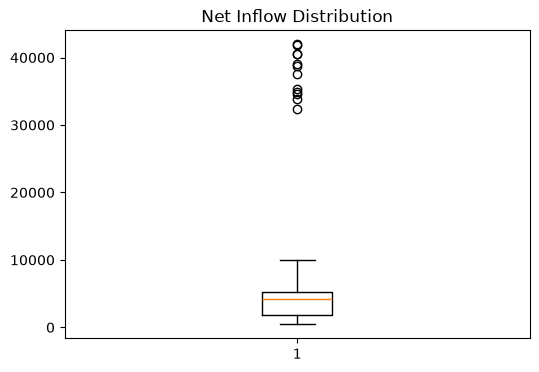

In [33]:
plt.figure(figsize=(6,4))
plt.boxplot(data["net_inflow_crore"])
plt.title("Net Inflow Distribution")
plt.show()

In [31]:
Q1 = data["net_inflow_crore"].quantile(0.25)
Q3 = data["net_inflow_crore"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data["net_inflow_crore"] < lower) |
    (data["net_inflow_crore"] > upper)
]

print("Outliers:", len(outliers))
outliers

Outliers: 12


,month,category,net_inflow_crore,is_outlier_net_inflow_crore
8,2024-04-01,Liquid,37537.0,True
20,2024-05-01,Liquid,41872.0,True
32,2024-06-01,Liquid,40486.0,True
44,2024-07-01,Liquid,34643.0,True
56,2024-08-01,Liquid,41952.0,True
68,2024-09-01,Liquid,35308.0,True
80,2024-10-01,Liquid,39091.0,True
92,2024-11-01,Liquid,40506.0,True
104,2024-12-01,Liquid,34933.0,True
116,2025-01-01,Liquid,33892.0,True


In [32]:
data = data.sort_values(["month", "category"])

In [34]:
data.to_csv("05_category_inflows_clean.csv", index=False)

In [35]:
print("Outlier Analysis: The IQR method identified multiple outliers in the net_inflow_crore column. After investigation, all outliers belonged to the Liquid category. Since Liquid funds naturally receive significantly higher inflows than other mutual fund categories, these values represent genuine business behavior rather than data-entry errors. Therefore, no outliers were removed.")

Outlier Analysis: The IQR method identified multiple outliers in the net_inflow_crore column. After investigation, all outliers belonged to the Liquid category. Since Liquid funds naturally receive significantly higher inflows than other mutual fund categories, these values represent genuine business behavior rather than data-entry errors. Therefore, no outliers were removed.
